文章直す
αカードは年に4回カードの入会CPを実施している。数ヶ月に一度定期的に開催されることが恒例化している。定期的に開催されているが、毎回CP時には数多くの申し込みがあり、CP期間に申し込みをする人とCP期間外に申し込みをする人で、退会までの日数や利用額に違いがあるのかを検定を実施しその差を図ることとする。

検定の流れ  
（１）退会について
CP期間中に申し込んだ人とCP期間外に申し込んだ人で、退会までの日数（早さ）に差があるかどうか。

（２）利用額について
CP期間中に申し込んだ人とCP期間外に申し込んだ人で、短期カード及び本カードの利用額に差があるかどうか。  
→①短期カード及び本カードの利用有無に差があるかどうか。  
→②短期カード及び本カードを一度でも利用した人について、利用額に差があるかどうか。

In [60]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm
sns.set_theme

<function seaborn.rcmod.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)>

（１）退会について  
CP期間中に申し込んだ人とCP期間外に申し込んだ人について、退会までの早さに差があるかを検証。

In [61]:
#CSVファイルの読み込み・内容の確認（入会・退会に関するデータ）
#withdrawal_days:20XX年度にαカードを申し込んだ人の本カード発行から退会までの日数。（本カード発行済の人のデータのみ。申込経路は統一。）
#count:20XX年度にαカードを申し込んだ人のうち、20XX年度~20XX+1年度の2年間でαカードを申し込んだ回数。（申込経路は統一。）
data0=pd.read_csv("nyuutaikai.csv")
data0.head()

,No,card,age,sex,withdrawal_days,count,CP
0,1,B,59,1,231,1,1
1,2,B,51,1,#VALUE!,1,1
2,3,B,78,1,#VALUE!,1,1
3,4,B,47,1,#VALUE!,1,1
4,5,B,57,1,#VALUE!,1,1


In [62]:
#データ全体の概要
data0.describe()

,No,age,sex,count,CP
count,76211.00000,76211.000000,76211.000000,76211.000000,76211.000000
mean,38106.00000,38.898755,0.834027,1.009710,0.583223
std,22000.36502,15.616298,0.372059,0.110278,0.493029
min,1.00000,19.000000,0.000000,1.000000,0.000000
25%,19053.50000,26.000000,1.000000,1.000000,0.000000
50%,38106.00000,33.000000,1.000000,1.000000,1.000000
75%,57158.50000,51.000000,1.000000,1.000000,1.000000
max,76211.00000,98.000000,1.000000,5.000000,1.000000


In [63]:
#欠損値の確認
print(data0.isnull().sum())

No                 0
card               0
age                0
sex                0
withdrawal_days    0
count              0
CP                 0
dtype: int64


In [64]:
#withdrawal_days列について、#VALUE!	エラーをNaNに置き換え
data0["withdrawal_days"]=data0["withdrawal_days"].replace("#VALUE!",np.nan).astype(float)

仮説1：CP期間中に申し込んだ人はCP期間外に申し込んだ人に比べて退会までの日数が短い。

In [6]:
#退会までの日数から、①90日（３ヶ月）以内退会フラグ、②180日（半年）以内退会フラグ、③365日（1年）以内退会フラグを立てる。
data0["flag90"]=(data0["withdrawal_days"]<=90).astype(int)
data0["flag180"]=(data0["withdrawal_days"]<=180).astype(int)
data0["flag365"]=(data0["withdrawal_days"]<=365).astype(int)
data0

,No,card,age,sex,withdrawal_days,count,CP,flag90,flag180,flag365
0,1,B,59,1,231.0,1,1,0,0,1
1,2,B,51,1,NaN,1,1,0,0,0
2,3,B,78,1,NaN,1,1,0,0,0
3,4,B,47,1,NaN,1,1,0,0,0
4,5,B,57,1,NaN,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
76206,76207,A,38,0,NaN,1,0,0,0,0
76207,76208,A,21,0,109.0,1,0,0,1,1
76208,76209,A,25,1,NaN,1,0,0,0,0
76209,76210,A,21,1,NaN,1,0,0,0,0


In [7]:
#連続値として認識されないよう、"sex","CP"列をそれぞれ文字列に変換（ダミー変数化の前処理）
data0["sex"]=data0["sex"].astype(str)
data0["CP"]=data0["CP"].astype(str)

In [8]:
#カテゴリ値のダミー変数化
data0_dummied=pd.get_dummies(data0)
data0_dummied.head()

,No,age,withdrawal_days,count,flag90,flag180,flag365,card_A,card_B,card_R,sex_0,sex_1,CP_0,CP_1
0,1,59,231.0,1,0,0,1,False,True,False,False,True,False,True
1,2,51,NaN,1,0,0,0,False,True,False,False,True,False,True
2,3,78,NaN,1,0,0,0,False,True,False,False,True,False,True
3,4,47,NaN,1,0,0,0,False,True,False,False,True,False,True
4,5,57,NaN,1,0,0,0,False,True,False,False,True,False,True


仮説1-1 CP期間中に申し込んだ人はCP期間外に申し込んだ人に比べて入会から90日以内に早期退会しやすい。

In [ ]:
#説明変数：CP期間内か否か、性別、年齢、カード種別で一般化線形モデルを作成
model90=smf.glm('flag90~CP_1+age+sex_1+card_A+card_B',data=data0_dummied,family=sm.families.Binomial()).fit()

In [10]:
print(model90.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 flag90   No. Observations:                76211
Model:                            GLM   Df Residuals:                    76205
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3980.1
Date:                Tue, 21 Apr 2026   Deviance:                       7960.2
Time:                        12:47:35   Pearson chi2:                 7.59e+04
No. Iterations:                     8   Pseudo R-squ. (CS):           0.001221
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.7519      0.150    -31.

仮説1-2 CP期間中に申し込んだ人はCP期間外に申し込んだ人に比べて入会から180日以内に早期退会しやすい。

In [ ]:
#説明変数：CP期間内か否か、性別、年齢、カード種別で一般化線形モデルを作成
model180=smf.glm('flag180~CP_1+age+sex_1+card_A+card_B',data=data0_dummied,family=sm.families.Binomial()).fit()

In [12]:
print(model180.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                flag180   No. Observations:                76211
Model:                            GLM   Df Residuals:                    76205
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -7718.0
Date:                Tue, 21 Apr 2026   Deviance:                       15436.
Time:                        12:47:53   Pearson chi2:                 7.60e+04
No. Iterations:                     7   Pseudo R-squ. (CS):           0.002330
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -4.0632      0.102    -39.

仮説1-3 CP期間中に申し込んだ人はCP期間外に申し込んだ人に比べて入会から365日以内に早期退会しやすい。

In [ ]:
#説明変数：CP期間内か否か、性別、年齢、カード種別で一般化線形モデルを作成
model365=smf.glm('flag365~CP_1+age+sex_1+card_A+card_B',data=data0_dummied,family=sm.families.Binomial()).fit()

In [14]:
print(model365.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                flag365   No. Observations:                76211
Model:                            GLM   Df Residuals:                    76205
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -21309.
Date:                Tue, 21 Apr 2026   Deviance:                       42618.
Time:                        12:48:10   Pearson chi2:                 7.62e+04
No. Iterations:                     6   Pseudo R-squ. (CS):           0.003696
Covariance Type:            nonrobust                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.7613      0.055    -49.

結果の解釈:  
①CPフラグにおけるP値が0.05以下であることから、CP期間中に申し込んだ否かは、短期（90日以内、180日以内、365日以内）に退会するかどうかに影響を与えている。また検証した3期間全てにおいて、退会までの日数に対してCPフラグの係数がマイナスとなったことから、CP期間外に申し込んだ人に比べてCP期間中に申し込んだ人の方が早期に退会しやすい。  
②性別は短期（90日以内、180日以内、365日以内）に退会するかどうかに比較的強く影響を与えており、特に90日以内退会においては強く影響を与えている。

In [15]:
#不要なら削除！！！
sns.boxplot(x="CP",y="withdrawal_days",data=taikai)

NameError: name 'taikai' is not defined

In [16]:
#不要なら削除！！！
sns.violinplot(x="CP",y="withdrawal_days",data=taikai)

NameError: name 'taikai' is not defined

（2）利用額について  
CP期間中に申し込んだ人とCP期間外に申し込んだ人について、短期カード（本カード発行前に発行される、有効期限の短い一時的なカード）と本カードの利用額についてそれぞれ差があるかどうかを検証。

In [15]:
#CSVファイルの読み込み・内容の確認（利用に関するデータ）
#ファイルはCP実施月ごとに４つのフォルダに分かれており、CP期間中とCP期間外の申し込みが判別できるようCPフラグを立てている。
#本データはCP実施月のみを対象としているため、CP未実施月の情報は含まれていない。
data1=pd.read_csv("riyou1.csv")
data2=pd.read_csv("riyou2.csv")
data3=pd.read_csv("riyou3.csv")
data4=pd.read_csv("riyou4.csv")

In [16]:
#CP実施月のカラムを追加
data1["month"]="1"
data2["month"]="2"
data3["month"]="3"
data4["month"]="4"

In [17]:
#データを1つにまとめる　#Noカラムの削除
#90days:本カードにおける発行後90日間の利用額。本カード発行日から起算。
#14days:短期カードにおける発行後14日間の利用額。短期カード発行日から起算。
data5=pd.concat([data1,data2,data3,data4])
data5=data5.drop(columns="No")
data5

,card,credit1,credit2,work,age,sex,90days,14days,CP,month
0,A,800000,300000,7,61,1,0.0,63065,1,1
1,A,1800000,1800000,4,59,1,34137.0,97397,1,1
2,A,800000,800000,12,77,1,0.0,33023,1,1
3,A,1200000,1200000,8,66,1,69692.0,41773,1,1
4,A,1300000,1300000,2,52,0,1280.0,66524,1,1
...,...,...,...,...,...,...,...,...,...,...
11744,A,700000,700000,2,29,0,0.0,35103,0,4
11745,A,600000,600000,2,28,0,117860.0,77425,0,4
11746,A,200000,200000,6,21,1,3000.0,11681,0,4
11747,A,200000,200000,2,26,0,0.0,23310,0,4


In [18]:
#データ全体の概要
data5.describe()

,credit1,credit2,work,age,sex,90days,14days,CP
count,4.269200e+04,4.269200e+04,42692.000000,42692.000000,42692.000000,3.932400e+04,42692.000000,42692.000000
mean,7.449557e+05,6.373068e+05,3.727513,38.394008,0.851003,7.197850e+04,35788.890354,0.878736
std,2.977336e+05,3.192847e+05,2.507159,15.018266,0.356090,4.049257e+05,39574.559315,0.326438
min,5.000000e+04,0.000000e+00,1.000000,19.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,5.000000e+05,3.000000e+05,2.000000,26.000000,1.000000,1.000000e+04,11082.750000,1.000000
50%,7.000000e+05,6.000000e+05,2.000000,33.000000,1.000000,3.452750e+04,23191.500000,1.000000
75%,1.000000e+06,9.000000e+05,6.000000,50.000000,1.000000,8.492150e+04,45429.750000,1.000000
max,2.000000e+06,1.800000e+06,13.000000,97.000000,1.000000,7.699478e+07,720000.000000,1.000000


In [19]:
#欠損値の確認
print(data5.isnull().sum())

card          0
credit1       0
credit2       0
work          0
age           0
sex           0
90days     3368
14days        0
CP            0
month         0
dtype: int64


In [20]:
#90days列の欠損値は全て「0円」であることがわかっているため、欠損値に0を補完
data5=data5.fillna(0)

In [21]:
#CP期間中/CP期間外申込者で分けたDataFrameを用意
data5_cp=data5.query("CP==1")
data5_notcp=data5.query("CP==0")

<Axes: xlabel='month', ylabel='14days'>

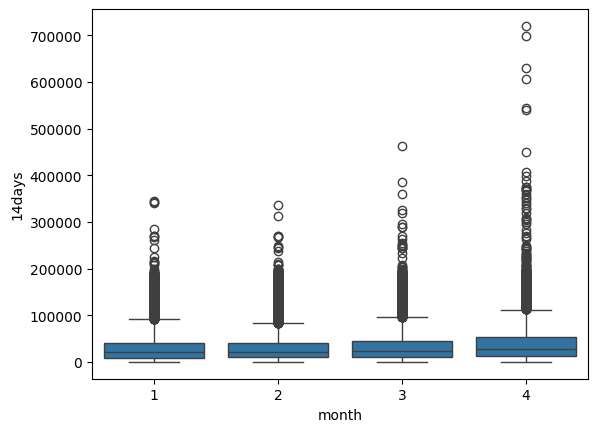

In [22]:
#短期カード発行日から14日間の短期カード利用額について、CP実施月により季節性が見られるか確認
sns.boxplot(x="month",y="14days",data=data5)

<Axes: xlabel='month', ylabel='14days'>

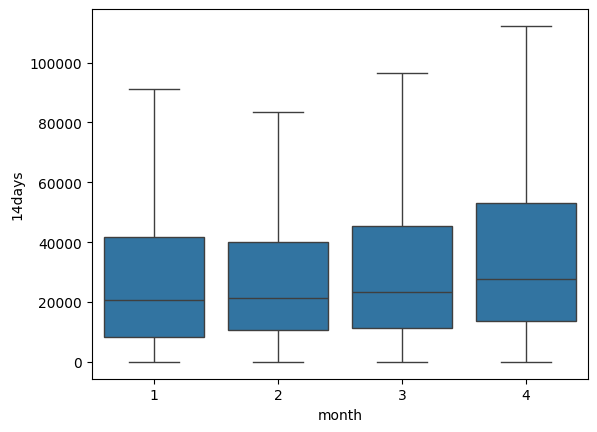

In [23]:
#外れ値の非表示
sns.boxplot(x="month",y="14days",data=data5,showfliers=False)

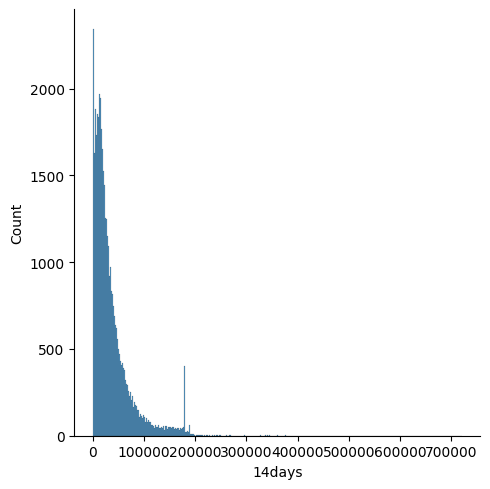

In [24]:
sns.displot(data5["14days"],kde=False)

<Axes: xlabel='month', ylabel='90days'>

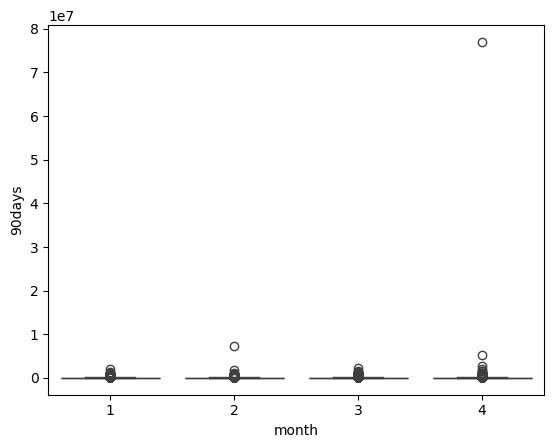

In [25]:
#本カード発行日から90日間の本カード利用額について、CP実施月により季節性が見られるか確認
sns.boxplot(x="month",y="90days",data=data5)

<Axes: xlabel='month', ylabel='90days'>

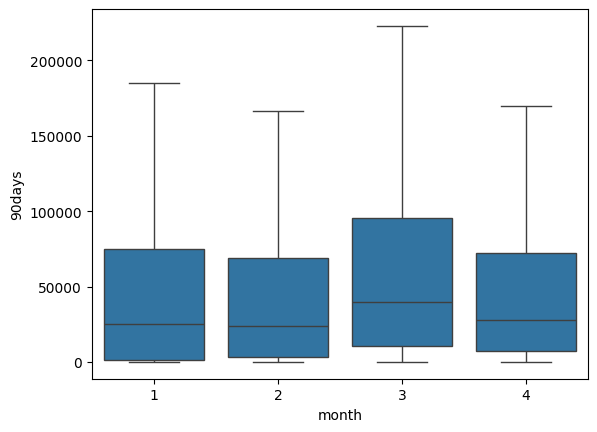

In [26]:
#外れ値の非表示
sns.boxplot(x="month",y="90days",data=data5,showfliers=False)

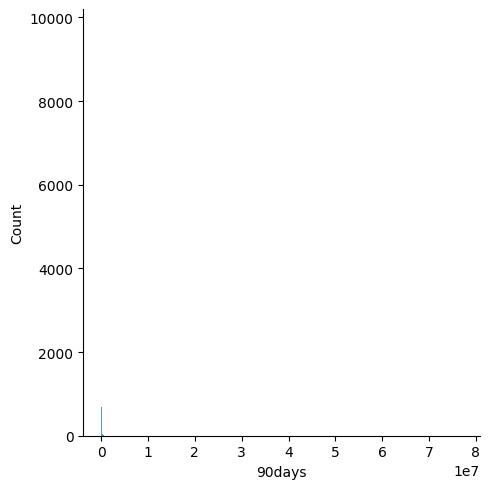

In [ ]:
#修正
sns.displot(data5["90days"],kde=False)

仮説2_1：CP期間中に申し込んだか否かは、短期カード発行後14日間における利用有無に影響を与える。

In [28]:
#14days,90daysそれぞれの利用について、利用有無フラグを立てる（利用額０円とそれ以外で分ける）
data5["riyouumu14"]=(data5["14days"]>0).astype(str)
data5["riyouumu90"]=(data5["90days"]>0).astype(str)

In [29]:
#DataFrameの内容を確認
data5

,card,credit1,credit2,work,age,sex,90days,14days,CP,month,riyouumu14,riyouumu90
0,A,800000,300000,7,61,1,0.0,63065,1,1,True,False
1,A,1800000,1800000,4,59,1,34137.0,97397,1,1,True,True
2,A,800000,800000,12,77,1,0.0,33023,1,1,True,False
3,A,1200000,1200000,8,66,1,69692.0,41773,1,1,True,True
4,A,1300000,1300000,2,52,0,1280.0,66524,1,1,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
11744,A,700000,700000,2,29,0,0.0,35103,0,4,True,False
11745,A,600000,600000,2,28,0,117860.0,77425,0,4,True,True
11746,A,200000,200000,6,21,1,3000.0,11681,0,4,True,True
11747,A,200000,200000,2,26,0,0.0,23310,0,4,True,False


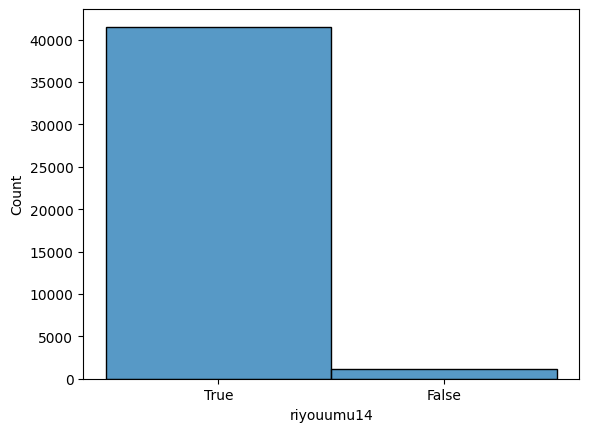

In [30]:
#短期カード発行後14日以内における利用有無の割合（True:利用あり,False:利用なし）
sns.histplot(data=data5,x="riyouumu14")
plt.show()

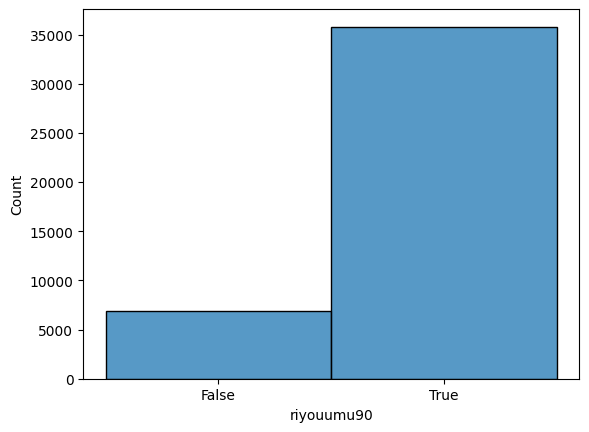

In [31]:
#本カード発行後90日以内における利用有無の割合（True:利用あり,False:利用なし）
sns.histplot(data=data5,x="riyouumu90")
plt.show()

In [ ]:
#変数同士の相関の確認


In [32]:
#連続値として認識されないよう、"sex","CP"列をカテゴリ値に置き換え(適切にダミー変数化が行われるよう調整)
data5["sex"]=data5["sex"].astype(str)
data5["CP"]=data5["CP"].astype(str)

In [33]:
#利用有無フラグをint型に変換（一般化線形モデル作成のため）
data5["riyouumu14"]=(data5["14days"]>0).astype(int)
data5["riyouumu90"]=(data5["90days"]>0).astype(int)

In [34]:
#カテゴリ値のダミー変数化
data5_dummied=pd.get_dummies(data5)
data5_dummied.head()

,credit1,credit2,work,age,90days,14days,riyouumu14,riyouumu90,card_A,card_B,card_R,sex_0,sex_1,CP_0,CP_1,month_1,month_2,month_3,month_4
0,800000,300000,7,61,0.0,63065,1,0,True,False,False,False,True,False,True,True,False,False,False
1,1800000,1800000,4,59,34137.0,97397,1,1,True,False,False,False,True,False,True,True,False,False,False
2,800000,800000,12,77,0.0,33023,1,0,True,False,False,False,True,False,True,True,False,False,False
3,1200000,1200000,8,66,69692.0,41773,1,1,True,False,False,False,True,False,True,True,False,False,False
4,1300000,1300000,2,52,1280.0,66524,1,1,True,False,False,True,False,False,True,True,False,False,False


In [35]:
#説明変数：CP期間内か否かのみで一般化線形モデルを作成
model1_1=smf.glm('riyouumu14~CP_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [36]:
print(model1_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu14   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42690
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3881.0
Date:                Tue, 21 Apr 2026   Deviance:                       7761.9
Time:                        12:55:40   Pearson chi2:                 4.27e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.06876
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.4954      0.036     41.613   

In [37]:
#説明変数：CP期間内か否か＋性別で一般化線形モデルを作成
model1_2=smf.glm('riyouumu14~CP_1+sex_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [38]:
print(model1_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu14   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42689
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3880.5
Date:                Tue, 21 Apr 2026   Deviance:                       7761.1
Time:                        12:55:54   Pearson chi2:                 4.27e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.06877
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.5679      0.088     17.799

In [39]:
#説明変数：CP期間内か否か＋性別+年齢で一般化線形モデルを作成
model1_3=smf.glm('riyouumu14~CP_1+sex_1+age',data=data5_dummied,family=sm.families.Binomial()).fit()

In [40]:
print(model1_3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu14   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42688
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -3880.2
Date:                Tue, 21 Apr 2026   Deviance:                       7760.4
Time:                        12:56:00   Pearson chi2:                 4.26e+04
No. Iterations:                     8   Pseudo R-squ. (CS):            0.06879
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.6381      0.121     13.522

In [41]:
#AICを比較
print("model1_1:",model1_1.aic)
print("model2_1:",model1_2.aic)
print("model3_1:",model1_3.aic)

model1_1: 7765.925614407251
model2_1: 7767.093290085725
model3_1: 7768.379933808526


仮説2_1に対する結果の解釈:  
CP期間中に申し込んだか否かは、短期カード発行後14日間における利用有無に影響を与える。CP期間中に申し込んだ人は、CP期間外に申し込んだ人に比べて利用する傾向が高い。

仮説2_2：CP期間中に申し込んだか否かは、本カード発行後90日間における利用有無に影響を与える。

In [42]:
#説明変数：CP期間内か否かのみで一般化線形モデルを作成
model2_1=smf.glm('riyouumu90~CP_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [43]:
print(model2_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42690
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18832.
Date:                Tue, 21 Apr 2026   Deviance:                       37664.
Time:                        12:56:33   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.001394
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.9426      0.042     46.283   

In [44]:
#説明変数：CP期間内か否か＋性別で一般化線形モデルを作成
model2_2=smf.glm('riyouumu90~CP_1+sex_1',data=data5_dummied,family=sm.families.Binomial()).fit()

In [45]:
print(model2_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42689
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18805.
Date:                Tue, 21 Apr 2026   Deviance:                       37609.
Time:                        12:56:36   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.002678
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.7188      0.051     33.598

In [46]:
#説明変数：CP期間内か否か＋性別＋年齢で一般化線形モデルを作成
model2_3=smf.glm('riyouumu90~CP_1+sex_1+age',data=data5_dummied,family=sm.families.Binomial()).fit()

In [47]:
print(model2_3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             riyouumu90   No. Observations:                42692
Model:                            GLM   Df Residuals:                    42688
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -18797.
Date:                Tue, 21 Apr 2026   Deviance:                       37595.
Time:                        12:56:40   Pearson chi2:                 4.27e+04
No. Iterations:                     5   Pseudo R-squ. (CS):           0.003009
Covariance Type:            nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         1.8512      0.062     29.801

In [48]:
#AICで比較
print("model2_1:",model2_1.aic)
print("model2_2:",model2_2.aic)
print("model2_3:",model2_3.aic)

model2_1: 37668.03799493565
model2_2: 37615.10631208525
model2_3: 37602.91412519116


仮説2_2に対する結果の解釈:  
CP期間中に申し込んだか否かは、本カード発行後90日間における利用有無に影響を与える。CP期間外に申し込んだ人は、CP期間中に申し込んだ人に比べて利用する傾向が若干高い。

仮説3_1：CP期間中に申し込んだ人とCP期間外に申し込んだ人では、短期カード発行後14日間における利用額に差がある。

In [49]:
#短期カードについて発行後14日間、本カードについて発行後90日間で一度でも利用有の人を抽出（それぞれ利用額0円の人を除外）
data5_14riyouari=data5.query("riyouumu14==1")
data5_90riyouari=data5.query("riyouumu90==1")

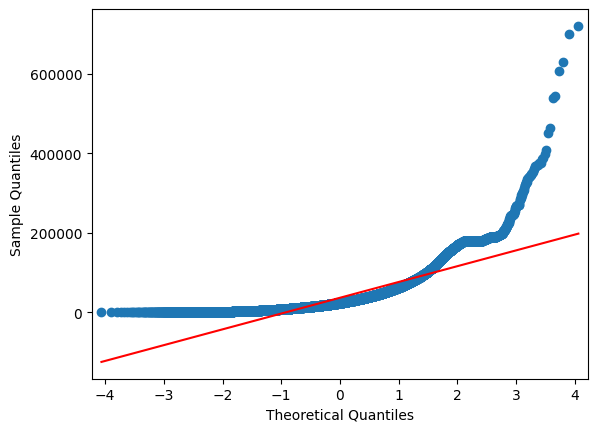

In [50]:
#正規性の確認（短期カードにおける発行後14日間の利用額）
fig_14=sm.qqplot(data5_14riyouari["14days"],line="s")

In [51]:
#対数変換
data5_14riyouari["14days"]=np.log1p(data5_14riyouari["14days"])

/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_834/625447555.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data5_14riyouari["14days"]=np.log1p(data5_14riyouari["14days"])


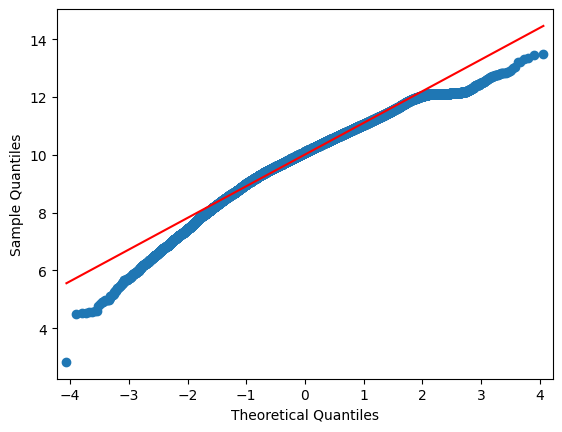

In [52]:
#対数変換後の正規性の確認
fig_14=sm.qqplot(data5_14riyouari["14days"],line="s")

In [53]:
#T検定のため、データをCPフラグの有無で分けそれぞれの短期カードにおける14日間利用額を抜き出す
group_cp14=data5_14riyouari[data5_14riyouari["CP"]=="1"]["14days"]
group_notcp14=data5_14riyouari[data5_14riyouari["CP"]=="0"]["14days"]

In [54]:
#T検定の実施
stats.ttest_ind(group_cp14,group_notcp14,equal_var=False)

TtestResult(statistic=np.float64(3.9770194217331416), pvalue=np.float64(7.075241626055848e-05), df=np.float64(5092.090427056045))

仮説3_1に対する結果の解釈:  
P値が0.05を下回ったので有意差がある、つまり「CP期間中に申し込んだ人とCP期間外に申し込んだ人では短期カード発行後14日間における利用額に差がある」。

仮説3_2:CP期間中に申し込んだ人とCP期間外に申し込んだ人では、本カード発行後90日間における利用額に差がある。

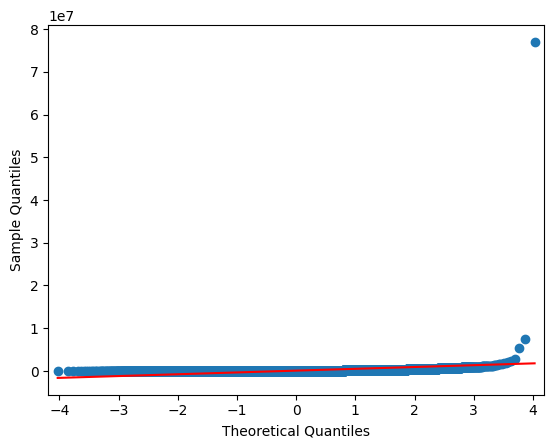

In [55]:
#正規性の確認（本カードにおける発行後90日間の利用額）
fig_90=sm.qqplot(data5_90riyouari["90days"],line="s")

In [56]:
#対数変換
data5_90riyouari["90days"]=np.log1p(data5_90riyouari["90days"])

/var/folders/cx/jds9b3yn25bbfv_r9qtyy0y00000gp/T/ipykernel_834/2718999111.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data5_90riyouari["90days"]=np.log1p(data5_90riyouari["90days"])


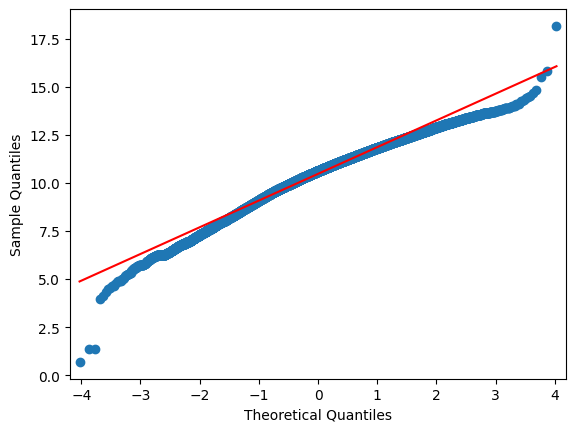

In [57]:
#対数変換後の正規性の確認
fig_90=sm.qqplot(data5_90riyouari["90days"],line="s")

In [58]:
#T検定のため、データをCPフラグの有無で分けてそれぞれの本カードにおける90日間利用額を抜き出す
group_cp90=data5_90riyouari[data5_90riyouari["CP"]=="1"]["90days"]
group_notcp90=data5_90riyouari[data5_90riyouari["CP"]=="0"]["90days"]

In [59]:
#T検定の実施
stats.ttest_ind(group_cp90,group_notcp90,equal_var=False)

TtestResult(statistic=np.float64(-7.757120397356574), pvalue=np.float64(1.0167417886767015e-14), df=np.float64(5906.493299426083))

仮説3_2に対する結果の解釈:  
P値が0.05を下回ったので有意差がある、つまり「CP期間中に申し込んだ人とCP期間外に申し込んだ人では本カード発行後90日間における利用額に差がある。

仮説4_1：CP実施月は短期カード発行後14日間利用額に影響を与える

In [129]:
#カテゴリ値のダミー変数化
data5_14riyouari_dummied=pd.get_dummies(data5_14riyouari)
data5_14riyouari_dummied.head()

,credit1,credit2,work,age,90days,14days,riyouumu14,riyouumu90,card_A,card_B,card_R,sex_0,sex_1,CP_0,CP_1,month_1,month_2,month_3,month_4
0,800000,300000,7,61,0.0,11.051937,1,0,True,False,False,False,True,False,True,True,False,False,False
1,1800000,1800000,4,59,34137.0,11.486561,1,1,True,False,False,False,True,False,True,True,False,False,False
2,800000,800000,12,77,0.0,10.404990,1,0,True,False,False,False,True,False,True,True,False,False,False
3,1200000,1200000,8,66,69692.0,10.640029,1,1,True,False,False,False,True,False,True,True,False,False,False
4,1300000,1300000,2,52,1280.0,11.105333,1,1,True,False,False,True,False,False,True,True,False,False,False


In [130]:
#一般化線形モデル作成のため、カラム名を一部変更
data5_14riyouari_dummied=data5_14riyouari_dummied.rename(columns={"90days":"days90","14days":"days14"})

In [133]:
#説明変数：CP期間内か否か＋CP実施月で一般化線形モデルを作成
model3_1=smf.glm('days14~CP_1+month_1+month_2+month_3',data=data5_14riyouari_dummied,family=sm.families.Binomial()).fit()

In [134]:
print(model3_1.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 days14   No. Observations:                41511
Model:                            GLM   Df Residuals:                    41506
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:             1.6956e+07
Date:                Tue, 21 Apr 2026   Deviance:                   2.8873e+07
Time:                        10:31:54   Pearson chi2:                 1.54e+22
No. Iterations:                     2   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept        6.239e+16   1.14e+06   5.

/Users/y-shibata/Downloads/dsdev/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/y-shibata/Downloads/dsdev/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1057: RuntimeWarning: invalid value encountered in log
  n * np.log(1 - mu + 1e-20)) * var_weights


仮説4_2：CP実施月は本カード発行後90日間利用額に影響を与える

In [135]:
#説明変数：CP期間内か否か＋CP実施月で一般化線形モデルを作成
model3_2=smf.glm('days90~CP_1+month_1+month_2+month_3',data=data5_14riyouari_dummied,family=sm.families.Binomial()).fit()

In [136]:
print(model3_2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 days90   No. Observations:                41511
Model:                            GLM   Df Residuals:                    41506
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                   -inf
Date:                Tue, 21 Apr 2026   Deviance:                   2.6389e+11
Time:                        10:32:25   Pearson chi2:                 2.99e+31
No. Iterations:                     2   Pseudo R-squ. (CS):                nan
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         3.53e+20   1.14e+06   3.

/Users/y-shibata/Downloads/dsdev/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1056: RuntimeWarning: invalid value encountered in log
  special.gammaln(n - y + 1) + y * np.log(mu / (1 - mu + 1e-20)) +
/Users/y-shibata/Downloads/dsdev/.venv/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1057: RuntimeWarning: invalid value encountered in log
  n * np.log(1 - mu + 1e-20)) * var_weights


→結果の解釈

＜まとめ＞
（１）退会について



（２）利用額について
　①短期カード発行後14日間及び本カード発行後90日間におけるカードの利用有無について

　②短期カード発行後14日間及び本カード発行後90日間におけるカードの利用額について（利用無の人を除外）
